# Customer Segmentation

In this project, I will group customers using:

- Annual Income
- Spending Score

I will use K-Means and also try DBSCAN as a bonus.


## 1. Import libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

## 2. Load the data

In [2]:
df = pd.read_csv("Mall_Customers.csv")

print(df.head())
print(df.shape)


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
(200, 5)


The dataset has 200 customers.

I will use income and spending score for the clustering.


## 3. Check the data

In [3]:
print(df.isnull().sum())

print(df[['Annual Income (k$)', 'Spending Score (1-100)']].describe())


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
       Annual Income (k$)  Spending Score (1-100)
count          200.000000              200.000000
mean            60.560000               50.200000
std             26.264721               25.823522
min             15.000000                1.000000
25%             41.500000               34.750000
50%             61.500000               50.000000
75%             78.000000               73.000000
max            137.000000               99.000000


## 4. Visualize the data

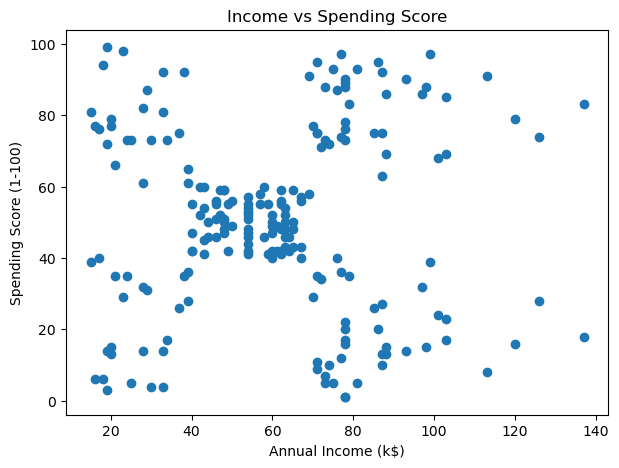

In [4]:
plt.figure(figsize=(7, 5))

plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'])

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Income vs Spending Score')
plt.show()


There are some clear groups in the plot.

Before K-Means, I will scale the two features so they have similar ranges.


## 5. Scale the data

In [5]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])


[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


## 6. Find the number of clusters

In [6]:
inertia = []
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)

    inertia.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))


e:\D_anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
e:\D_anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
e:\D_anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
e:\D_anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than 

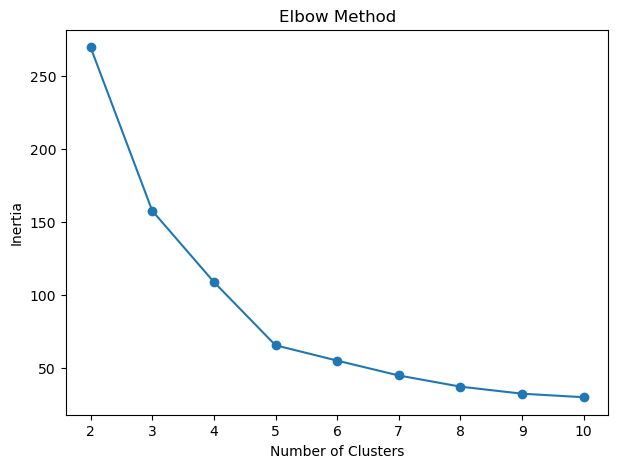

In [7]:
plt.figure(figsize=(7, 5))

plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


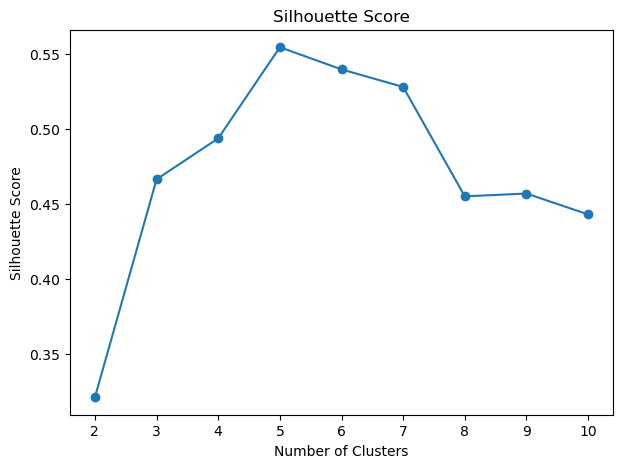

Best k from silhouette score: 5


In [8]:
plt.figure(figsize=(7, 5))

plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.show()

best_k = k_values[silhouette_scores.index(max(silhouette_scores))]
print('Best k from silhouette score:', best_k)


The elbow plot shows a clear change around 5 clusters.

The silhouette score is also highest at 5, so I will use 5 clusters.


## 7. K-Means clustering

In [9]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df.head())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


e:\D_anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## 8. Visualize the clusters

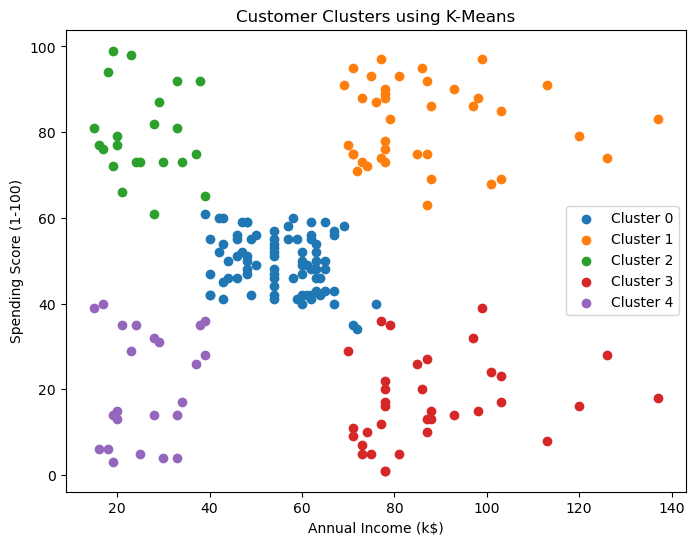

In [10]:
plt.figure(figsize=(8, 6))

for cluster in sorted(df['Cluster'].unique()):
    data = df[df['Cluster'] == cluster]

    plt.scatter(data['Annual Income (k$)'],
                data['Spending Score (1-100)'],
                label=f'Cluster {cluster}')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Clusters using K-Means')
plt.legend()
plt.show()


## 9. Average spending in each cluster

In [11]:
cluster_summary = df.groupby('Cluster').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean'
}).round(2)

print(cluster_summary)


         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                     55.30                   49.52
1                     86.54                   82.13
2                     25.73                   79.36
3                     88.20                   17.11
4                     26.30                   20.91


In [12]:
cluster_size = df['Cluster'].value_counts().sort_index()

print('Number of customers in each cluster:')
print(cluster_size)


Number of customers in each cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


The average spending score helps us understand the groups.

A higher spending score means the customers in that cluster usually spend more.


## 10. Bonus: DBSCAN

In [13]:
dbscan = DBSCAN(eps=0.4, min_samples=5)

df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

print(df['DBSCAN_Cluster'].value_counts().sort_index())


DBSCAN_Cluster
-1     15
 0    115
 1     11
 2     32
 3     27
Name: count, dtype: int64


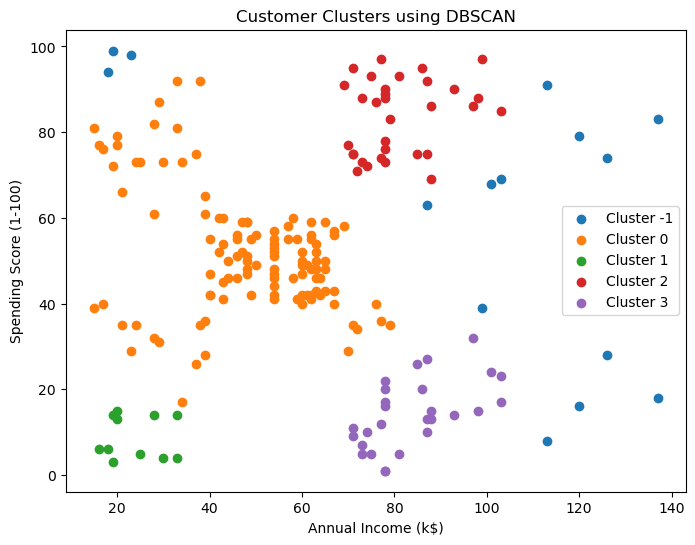

In [14]:
plt.figure(figsize=(8, 6))

for cluster in sorted(df['DBSCAN_Cluster'].unique()):
    data = df[df['DBSCAN_Cluster'] == cluster]

    plt.scatter(data['Annual Income (k$)'],
                data['Spending Score (1-100)'],
                label=f'Cluster {cluster}')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Clusters using DBSCAN')
plt.legend()
plt.show()


DBSCAN finds groups based on density and can also mark some points as noise.

For this dataset, K-Means gives the clearer customer segments for income and spending score.


## 11. Conclusion

K-Means was used to divide the customers into 5 groups.

The clusters are based on annual income and spending score, and the average values help describe each group.

DBSCAN was also tested as a bonus.
